# 3_analise.ipynb — Camada Gold, perguntas de negócio e gráficos

**Projeto:** Viagens a Serviço (Portal da Transparência) · **Camadas:** Raw → Silver → **Gold**

Este notebook é a **Fase 3** do pipeline. Ele lê as tabelas Silver (já limpas e tipadas pelo `2_transformar.py`), cria a camada **Gold** (tabelas e *views* agregadas) e responde as **7 perguntas de negócio**. Cada pergunta segue o mesmo caminho: **pergunta → consulta SQL → tabela → gráfico → conclusão**.

**Regra de análise adotada:** todas as perguntas consideram **apenas viagens realizadas** (`situacao = 'Realizada'`). Viagens que não aconteceram não representam gasto nem deslocamento de fato.

| Camada | Perguntas |
|---|---|
| Silver (consulta direta) | 1. órgãos com maior custo · 2. destinos com maior custo médio · 3. viagem de maior duração |
| Gold (tabela e view com `JOIN` + `GROUP BY`) | 4. tipo de pagamento com maior valor médio · 5. meio de transporte mais usado · 6. UF de destino mais frequente · 7. órgão que mais pagou |

**Antes de executar:** rode `0_criar_banco.sql`, `1_extrair.py` e `2_transformar.py`, e confira o `.env` com a sua senha do PostgreSQL.

## Preparação: bibliotecas e conexão

`pandas` organiza o resultado das consultas em tabelas, `matplotlib` desenha os gráficos e `banco.conectar()` abre a conexão com o banco `transparencia`, usando a senha do arquivo `.env`.

A função `consultar()` executa uma consulta SQL e devolve o resultado como tabela do Pandas (é o `pd.read_sql()` que você já usou), abrindo e fechando a conexão a cada chamada. A função `formatar_numero()` escreve números no padrão brasileiro (`1.234,56`). O `pd.set_option("display.float_format", ...)` faz as tabelas mostrarem os números com 2 casas decimais, em vez da notação científica (`4.857482e+08`).

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

from banco import conectar

warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

# mostra os números das tabelas com 2 casas decimais (sem a notação 4.857482e+08)
pd.set_option("display.float_format", "{:.2f}".format)


def consultar(sql):
    conexao = conectar()
    tabela = pd.read_sql(sql, conexao)
    conexao.close()
    return tabela


def formatar_numero(valor, casas=2):
    texto = f"{valor:,.{casas}f}"
    return texto.replace(",", "X").replace(".", ",").replace("X", ".")


teste = consultar("SELECT COUNT(*) AS viagens FROM silver_viagem")
print("Conexão OK. Viagens na camada Silver:", teste["viagens"][0])

Conexão OK. Viagens na camada Silver: 341860


---
# Parte A — Perguntas respondidas direto na camada Silver

## Pergunta 1 — Quais são os 5 órgãos com maior custo total?

O custo de uma viagem é a coluna `valor_total` (diárias + passagens + outros gastos − devolução). A consulta soma o custo por **órgão superior** (`GROUP BY`), ordena do maior para o menor (`ORDER BY ... DESC`) e fica com os 5 primeiros (`LIMIT 5`).

,orgao,custo_total,custo_milhoes
0,Ministério da Justiça e Segurança Pública,485748241.43,485.75
1,Ministério da Defesa,154595910.29,154.60
2,Ministério da Educação,109759836.03,109.76
3,Ministério do Meio Ambiente e Mudança do Clima,49300595.26,49.30
4,Ministério da Previdência Social,40236180.79,40.24


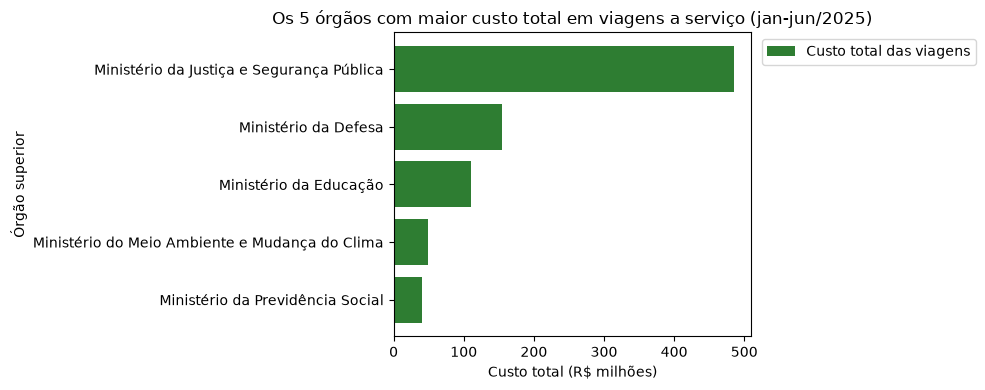

Conclusão: o Ministério da Justiça e Segurança Pública lidera, com R$ 485,7 milhões. Isso equivale a 1,4 vez o custo dos outros 4 órgãos do ranking somados.


In [2]:
tabela = consultar("""
    SELECT nome_orgao_superior AS orgao,
           SUM(valor_total) AS custo_total
    FROM silver_viagem
    WHERE situacao = 'Realizada'
    GROUP BY nome_orgao_superior
    ORDER BY custo_total DESC
    LIMIT 5
""")
tabela["custo_milhoes"] = tabela["custo_total"] / 1_000_000
display(tabela)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(tabela["orgao"], tabela["custo_milhoes"], color="#2E7D32", label="Custo total das viagens")
ax.invert_yaxis()
ax.set_title("Os 5 órgãos com maior custo total em viagens a serviço (jan-jun/2025)")
ax.set_xlabel("Custo total (R$ milhões)")
ax.set_ylabel("Órgão superior")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))  # legenda fora do gráfico, para não cobrir as barras
plt.tight_layout()
plt.show()

lider = tabela.iloc[0]
outros = tabela["custo_total"].iloc[1:].sum()
print(f"Conclusão: o {lider['orgao']} lidera, com R$ {formatar_numero(lider['custo_milhoes'], 1)} milhões. "
      f"Isso equivale a {formatar_numero(lider['custo_total'] / outros, 1)} vez o custo dos outros 4 órgãos do ranking somados.")

## Pergunta 2 — Quais são os 3 destinos com maior custo médio por viagem?

Aqui existe um cuidado. A coluna `destinos` é um **texto livre**: uma viagem pode listar várias cidades (`Londres/Reino Unido, Brasília/DF`). Cada combinação diferente de texto vira um "destino" no `GROUP BY`.

A média de um grupo **muito pequeno engana**: uma única viagem caríssima a um destino raro ficaria em primeiro lugar. Por isso a consulta usa `HAVING COUNT(*) >= 100`, que só aceita destinos com **pelo menos 100 viagens**. O `HAVING` filtra os **grupos** depois de agrupar (o `WHERE` filtra as linhas antes).

,destino,viagens,custo_medio
0,"Brasília/DF, Brasília/DF",283,27401.80
1,Genebra/Suíça,242,25469.22
2,Nova York/Estados Unidos da América,149,21214.19


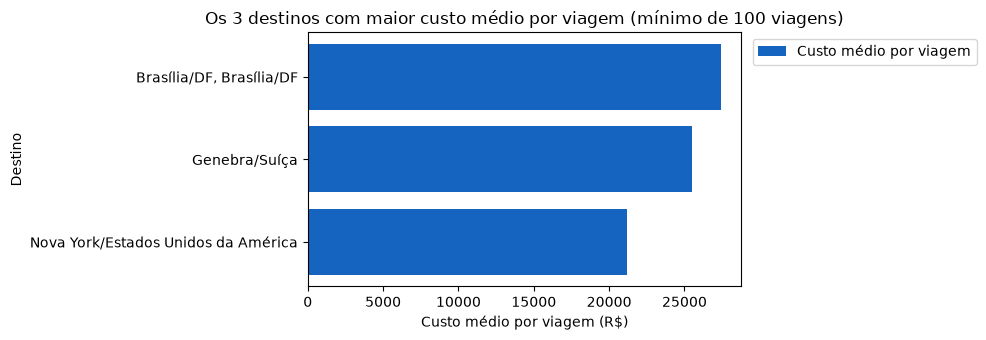

Conclusão: 'Brasília/DF, Brasília/DF' tem o maior custo médio, R$ 27.401,80 por viagem, em 283 viagens. Só entram destinos com 100 viagens ou mais, para a média não ser enganosa.


In [3]:
tabela = consultar("""
    SELECT destinos AS destino,
           COUNT(*) AS viagens,
           ROUND(AVG(valor_total), 2) AS custo_medio
    FROM silver_viagem
    WHERE situacao = 'Realizada'
    GROUP BY destinos
    HAVING COUNT(*) >= 100
    ORDER BY custo_medio DESC
    LIMIT 3
""")
display(tabela)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.barh(tabela["destino"], tabela["custo_medio"], color="#1565C0", label="Custo médio por viagem")
ax.invert_yaxis()
ax.set_title("Os 3 destinos com maior custo médio por viagem (mínimo de 100 viagens)")
ax.set_xlabel("Custo médio por viagem (R$)")
ax.set_ylabel("Destino")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))  # legenda fora do gráfico, para não cobrir as barras
plt.tight_layout()
plt.show()

lider = tabela.iloc[0]
print(f"Conclusão: '{lider['destino']}' tem o maior custo médio, R$ {formatar_numero(lider['custo_medio'])} por viagem, "
      f"em {lider['viagens']} viagens. Só entram destinos com 100 viagens ou mais, para a média não ser enganosa.")

## Pergunta 3 — Qual é a viagem de maior duração e qual foi o seu custo total?

A coluna `duracao_dias` foi calculada no `2_transformar.py` como `(data_fim - data_inicio) + 1`. A consulta ordena da maior duração para a menor e mostra as 5 maiores, para o gráfico ter comparação. O filtro `duracao_dias IS NOT NULL` evita que viagens sem datas apareçam antes das outras.

,id_viagem,orgao,data_inicio,data_fim,duracao_dias,valor_total
0,0000000000020699856,Ministério da Previdência Social,2025-01-13,2026-01-31,384,0.00
1,0000000000020793594,Ministério da Justiça e Segurança Pública,2025-01-02,2026-01-15,379,120650.00
2,0000000000020793492,Ministério da Justiça e Segurança Pública,2025-01-11,2026-01-15,370,113382.50
3,0000000000020774569,Ministério da Educação,2025-02-26,2026-03-02,370,0.00
4,0000000000020592696,Ministério da Justiça e Segurança Pública,2025-01-01,2026-01-02,367,159044.90


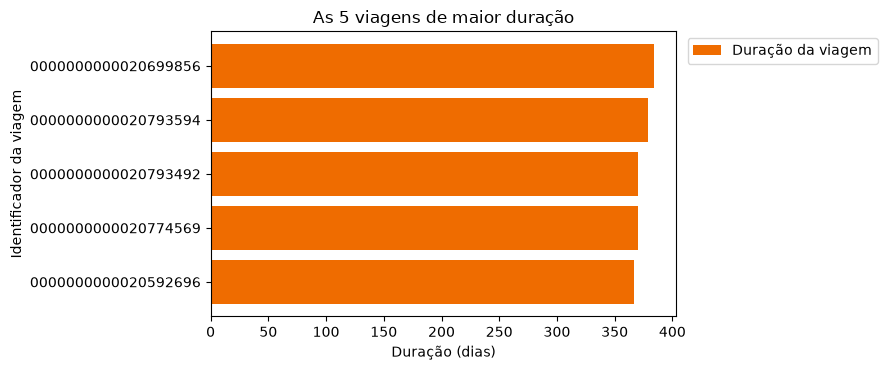

Conclusão: a viagem 0000000000020699856 (Ministério da Previdência Social) é a mais longa, com 384 dias (de 2025-01-13 a 2026-01-31). Custo total registrado: R$ 0,00.


In [4]:
tabela = consultar("""
    SELECT id_viagem,
           nome_orgao_superior AS orgao,
           data_inicio,
           data_fim,
           duracao_dias,
           valor_total
    FROM silver_viagem
    WHERE situacao = 'Realizada' AND duracao_dias IS NOT NULL
    ORDER BY duracao_dias DESC, valor_total DESC
    LIMIT 5
""")
display(tabela)

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.barh(tabela["id_viagem"], tabela["duracao_dias"], color="#EF6C00", label="Duração da viagem")
ax.invert_yaxis()
ax.set_title("As 5 viagens de maior duração")
ax.set_xlabel("Duração (dias)")
ax.set_ylabel("Identificador da viagem")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))  # legenda fora do gráfico, para não cobrir as barras
plt.tight_layout()
plt.show()

maior = tabela.iloc[0]
print(f"Conclusão: a viagem {maior['id_viagem']} ({maior['orgao']}) é a mais longa, com {maior['duracao_dias']} dias "
      f"(de {maior['data_inicio']} a {maior['data_fim']}). Custo total registrado: R$ {formatar_numero(maior['valor_total'])}.")

---
# Parte B — Camada Gold

A camada **Gold** guarda dados **já agregados** para responder perguntas de negócio. Cada tabela Gold nasce de um `JOIN` (juntar duas tabelas Silver pela chave `id_viagem`) com um `GROUP BY` (agrupar e somar/contar). Criamos **duas versões** de cada uma:

| | Tabela (`CREATE TABLE ... AS`) | View (`CREATE VIEW ... AS`) |
|---|---|---|
| O que guarda | o resultado, gravado uma vez, na hora da criação | só a consulta; recalcula a cada leitura |
| Quando o dado de origem muda | continua com o dado antigo até ser recriada | acompanha o dado de origem |

Os comandos `DROP TABLE IF EXISTS` e `CREATE OR REPLACE VIEW` permitem rodar a célula de novo sem erro.

- **`gold_pagamento_resumo`**: junta `silver_pagamento` com `silver_viagem` e soma os pagamentos por órgão pagador e tipo de pagamento (só de viagens realizadas).
- **`gold_trecho_resumo`**: junta `silver_trecho` com `silver_viagem` e conta os trechos por meio de transporte e UF de destino (só de viagens realizadas).

In [5]:
from banco import conectar

CONSULTA_PAGAMENTO = """
    SELECT p.nome_orgao_pagador,
           p.tipo_pagamento,
           COUNT(*) AS qtd_pagamentos,
           SUM(p.valor) AS total_pago
    FROM silver_pagamento p
    JOIN silver_viagem v ON v.id_viagem = p.id_viagem
    WHERE v.situacao = 'Realizada'
    GROUP BY p.nome_orgao_pagador, p.tipo_pagamento
"""

CONSULTA_TRECHO = """
    SELECT t.meio_transporte,
           t.destino_uf,
           COUNT(*) AS qtd_trechos
    FROM silver_trecho t
    JOIN silver_viagem v ON v.id_viagem = t.id_viagem
    WHERE v.situacao = 'Realizada'
    GROUP BY t.meio_transporte, t.destino_uf
"""

conexao = conectar()
try:
    cursor = conexao.cursor()
    cursor.execute("DROP TABLE IF EXISTS gold_pagamento_resumo")
    cursor.execute("CREATE TABLE gold_pagamento_resumo AS " + CONSULTA_PAGAMENTO)
    cursor.execute("CREATE OR REPLACE VIEW vw_gold_pagamento_resumo AS " + CONSULTA_PAGAMENTO)

    cursor.execute("DROP TABLE IF EXISTS gold_trecho_resumo")
    cursor.execute("CREATE TABLE gold_trecho_resumo AS " + CONSULTA_TRECHO)
    cursor.execute("CREATE OR REPLACE VIEW vw_gold_trecho_resumo AS " + CONSULTA_TRECHO)

    conexao.commit()
    print("Camada Gold criada: 2 tabelas e 2 views.")
except Exception as erro:
    conexao.rollback()
    print("ERRO ao criar a camada Gold:", type(erro).__name__, erro)
finally:
    conexao.close()

Camada Gold criada: 2 tabelas e 2 views.


**Conferência:** a tabela e a view foram criadas a partir da mesma consulta, então, neste momento, precisam ter a **mesma quantidade de linhas**.

In [6]:
conexao = conectar()
cursor = conexao.cursor()
for tabela_gold, visao_gold in [("gold_pagamento_resumo", "vw_gold_pagamento_resumo"),
                                ("gold_trecho_resumo", "vw_gold_trecho_resumo")]:
    cursor.execute(f"SELECT COUNT(*) FROM {tabela_gold}")
    linhas_tabela = cursor.fetchone()[0]
    cursor.execute(f"SELECT COUNT(*) FROM {visao_gold}")
    linhas_view = cursor.fetchone()[0]
    situacao = "OK" if linhas_tabela == linhas_view else "DIFERENTE!"
    print(f"{tabela_gold}: {linhas_tabela} linhas | {visao_gold}: {linhas_view} linhas -> {situacao}")
conexao.close()

gold_pagamento_resumo: 655 linhas | vw_gold_pagamento_resumo: 655 linhas -> OK


gold_trecho_resumo: 201 linhas | vw_gold_trecho_resumo: 201 linhas -> OK


## Pergunta 4 — Qual tipo de pagamento tem o maior valor médio?

O `::INT` converte a soma para número inteiro (sem o `.0` no fim). A média de cada tipo **não** pode ser feita com a média das médias da Gold (cada linha tem um número diferente de pagamentos). O correto é **somar tudo o que foi pago** e **dividir pelo total de pagamentos**: `SUM(total_pago) / SUM(qtd_pagamentos)`.

,tipo_pagamento,pagamentos,valor_medio
0,DIÁRIAS,400364,2078.79
1,PASSAGEM,182883,1882.32
2,Serviço correlato: seguro,4789,447.26
3,RESTITUIÇÃO,11574,245.70


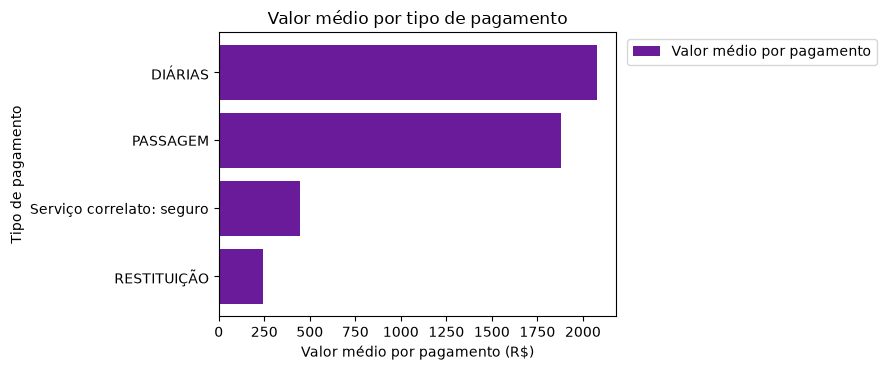

Conclusão: o tipo 'DIÁRIAS' tem o maior valor médio, R$ 2.078,79 por pagamento, em 400.364 pagamentos.


In [7]:
tabela = consultar("""
    SELECT tipo_pagamento,
           SUM(qtd_pagamentos)::INT AS pagamentos,
           ROUND(SUM(total_pago) / SUM(qtd_pagamentos), 2) AS valor_medio
    FROM gold_pagamento_resumo
    GROUP BY tipo_pagamento
    ORDER BY valor_medio DESC
""")
display(tabela)

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.barh(tabela["tipo_pagamento"], tabela["valor_medio"], color="#6A1B9A", label="Valor médio por pagamento")
ax.invert_yaxis()
ax.set_title("Valor médio por tipo de pagamento")
ax.set_xlabel("Valor médio por pagamento (R$)")
ax.set_ylabel("Tipo de pagamento")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))  # legenda fora do gráfico, para não cobrir as barras
plt.tight_layout()
plt.show()

lider = tabela.iloc[0]
print(f"Conclusão: o tipo '{lider['tipo_pagamento']}' tem o maior valor médio, R$ {formatar_numero(lider['valor_medio'])} "
      f"por pagamento, em {formatar_numero(lider['pagamentos'], 0)} pagamentos.")

## Pergunta 5 — Qual meio de transporte é o mais usado nos trechos?

,meio_transporte,trechos
0,Veículo Oficial,385734
1,Aéreo,226707
2,Rodoviário,64454
3,Veículo Próprio,42736
4,Inválido,26523
5,Fluvial,8392
6,Ferroviário,868
7,Marítimo,471


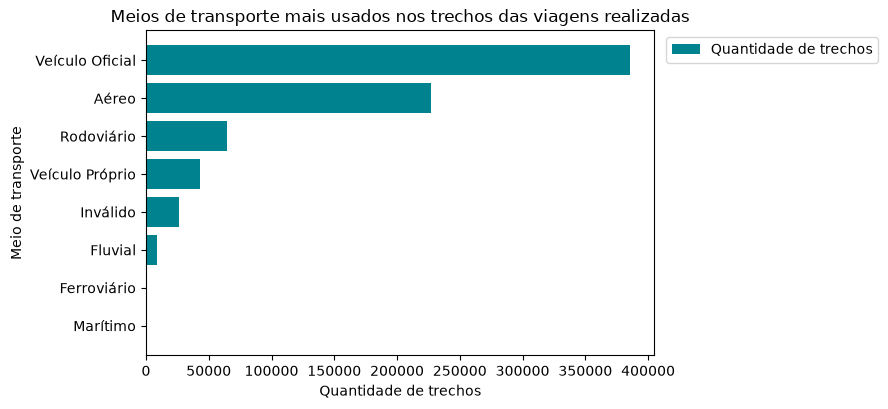

Conclusão: 'Veículo Oficial' é o meio mais usado, com 385.734 trechos (51,0% do total de 755.885).


In [8]:
tabela = consultar("""
    SELECT meio_transporte,
           SUM(qtd_trechos)::INT AS trechos
    FROM gold_trecho_resumo
    GROUP BY meio_transporte
    ORDER BY trechos DESC
""")
display(tabela)

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.barh(tabela["meio_transporte"], tabela["trechos"], color="#00838F", label="Quantidade de trechos")
ax.invert_yaxis()
ax.set_title("Meios de transporte mais usados nos trechos das viagens realizadas")
ax.set_xlabel("Quantidade de trechos")
ax.set_ylabel("Meio de transporte")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))  # legenda fora do gráfico, para não cobrir as barras
plt.tight_layout()
plt.show()

lider = tabela.iloc[0]
total = tabela["trechos"].sum()
print(f"Conclusão: '{lider['meio_transporte']}' é o meio mais usado, com {formatar_numero(lider['trechos'], 0)} trechos "
      f"({formatar_numero(lider['trechos'] / total * 100, 1)}% do total de {formatar_numero(total, 0)}).")

## Pergunta 6 — Qual UF de destino aparece em mais trechos?

O gráfico mostra as 10 UFs mais frequentes.

,uf,trechos
0,São Paulo,81727
1,Distrito Federal,77962
2,Minas Gerais,50555
3,Rio de Janeiro,43481
4,Paraná,42323
5,Pará,39742
6,Rio Grande do Sul,38397
7,Mato Grosso do Sul,30450
8,Bahia,28141
9,Pernambuco,28117


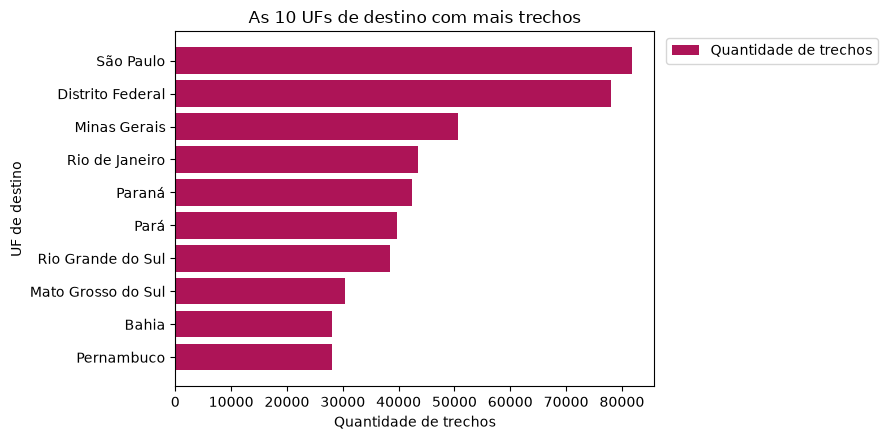

Conclusão: São Paulo é a UF de destino mais frequente, com 81.727 trechos.


In [9]:
tabela = consultar("""
    SELECT destino_uf AS uf,
           SUM(qtd_trechos)::INT AS trechos
    FROM gold_trecho_resumo
    GROUP BY destino_uf
    ORDER BY trechos DESC
    LIMIT 10
""")
display(tabela)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(tabela["uf"], tabela["trechos"], color="#AD1457", label="Quantidade de trechos")
ax.invert_yaxis()
ax.set_title("As 10 UFs de destino com mais trechos")
ax.set_xlabel("Quantidade de trechos")
ax.set_ylabel("UF de destino")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))  # legenda fora do gráfico, para não cobrir as barras
plt.tight_layout()
plt.show()

lider = tabela.iloc[0]
print(f"Conclusão: {lider['uf']} é a UF de destino mais frequente, com {formatar_numero(lider['trechos'], 0)} trechos.")

## Pergunta 7 — Qual órgão pagou mais no total?

Aqui o que interessa é o **órgão pagador** (quem efetivamente pagou), que pode ser diferente do órgão superior da Pergunta 1 (quem gastou). O gráfico mostra os 5 maiores.

,orgao_pagador,total_pago,total_milhoes
0,Fundo Nacional de Segurança Pública,278288685.42,278.29
1,Sigiloso,199308482.09,199.31
2,Comando da Aeronáutica,81069602.67,81.07
3,Instituto Nacional do Seguro Social,37254697.89,37.25
4,Comando do Exército,36576135.70,36.58


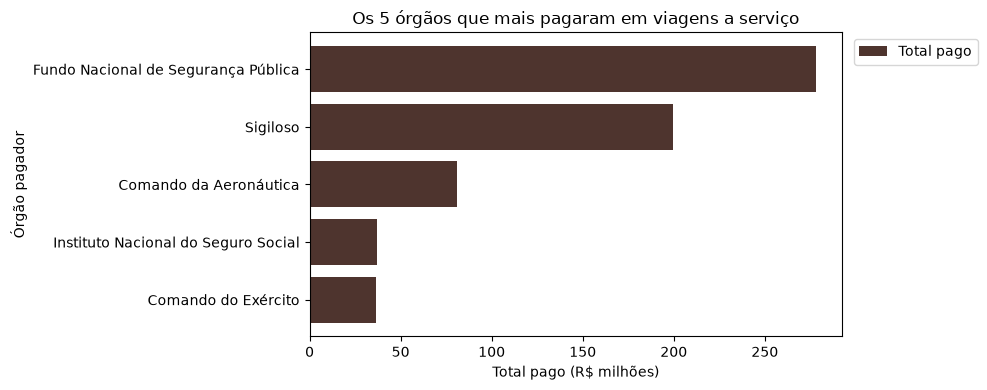

Conclusão: o Fundo Nacional de Segurança Pública foi quem mais pagou, R$ 278,3 milhões.


In [10]:
tabela = consultar("""
    SELECT nome_orgao_pagador AS orgao_pagador,
           SUM(total_pago) AS total_pago
    FROM gold_pagamento_resumo
    GROUP BY nome_orgao_pagador
    ORDER BY total_pago DESC
    LIMIT 5
""")
tabela["total_milhoes"] = tabela["total_pago"] / 1_000_000
display(tabela)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(tabela["orgao_pagador"], tabela["total_milhoes"], color="#4E342E", label="Total pago")
ax.invert_yaxis()
ax.set_title("Os 5 órgãos que mais pagaram em viagens a serviço")
ax.set_xlabel("Total pago (R$ milhões)")
ax.set_ylabel("Órgão pagador")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))  # legenda fora do gráfico, para não cobrir as barras
plt.tight_layout()
plt.show()

lider = tabela.iloc[0]
print(f"Conclusão: o {lider['orgao_pagador']} foi quem mais pagou, R$ {formatar_numero(lider['total_milhoes'], 1)} milhões.")

---
# Decisões e limitações da análise

- **Só viagens realizadas.** Todas as perguntas filtram `situacao = 'Realizada'`.
- **Custo total da viagem** = diárias + passagens + outros gastos − devolução. O enunciado não define a fórmula; esta é a escolha adotada e está no `2_transformar.py`.
- **Duração** = `(data_fim - data_inicio) + 1` dia (conta o dia de início e o de fim).
- **Destinos (Pergunta 2):** `destinos` é texto livre, e uma mesma cidade pode aparecer repetida na lista. A análise trata cada texto igual como um destino e exige **100 viagens ou mais** por destino; uma limpeza melhor (separar as cidades) é uma melhoria possível.
- **Órgão pagador (Pergunta 7):** a base tem um pagador chamado "Sigiloso", que aparece entre os maiores e não identifica o órgão real.
- **Meio de transporte (Pergunta 5):** a base tem a categoria "Inválido", mantida como veio da fonte.
- **Média do valor por tipo de pagamento (Pergunta 4):** calculada como total pago ÷ quantidade de pagamentos, para não tirar média de médias.